In [2]:
# Q2. Unsupervised Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Task 1. Data Preparation

# Loading Data
customers = pd.read_csv('data/q2_customers.csv')

# Scaling all features and keeping Dataframe format 
scaler = StandardScaler()
customers_scaled = pd.DataFrame(
    scaler.fit_transform(customers),
    columns=customers.columns
)
print(customers_scaled)


          age  annual_spend  visits_per_month  basket_size  \
0   -0.725219     -0.176150          0.110166    -0.265011   
1   -1.488460     -1.046826          0.486157    -0.980466   
2    0.176795      0.267337         -0.453822    -0.236851   
3   -0.725219     -1.012309          0.298161    -0.827783   
4   -1.488460     -1.034488          1.426136    -1.005986   
..        ...           ...               ...          ...   
495 -1.419075     -0.815349          0.862149    -0.859463   
496  0.870651      0.456620         -1.393801     2.063076   
497  0.246180      0.143220          0.110166    -0.781582   
498 -0.308905     -0.233212          0.110166    -0.279972   
499 -1.419075     -1.241136          1.238140    -0.799622   

     days_since_last_visit  num_categories_purchased  
0                -0.089951                  0.550952  
1                -0.835176                 -0.680685  
2                -0.674046                 -0.270139  
3                -0.996306         

In the dataset, different features have significantly different ranges—for example, annual spend ranges from 5,000 to 119,000, age ranges from 18 to 70, visits per month range from 1 to 19, and basket size ranges from 200 to 7,900. Due to these differences, features with larger numerical values, such as annual spend, would dominate the distance calculations in K-Means clustering. As a result, smaller-scale features like age and visits per month would have minimal influence on cluster formation. Therefore, scaling is essential to bring all features to a comparable range, ensuring that each feature contributes equally to the clustering process and leading to more meaningful and balanced clusters.

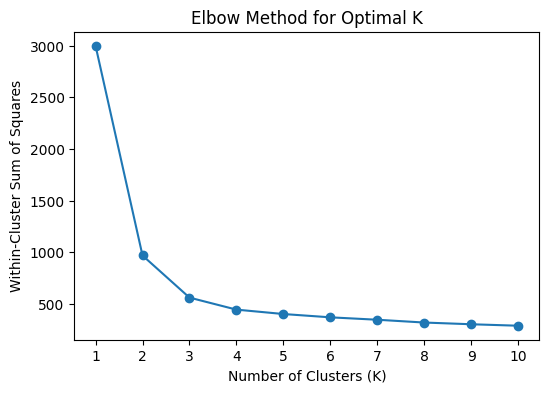

In [3]:
# Task 2. Choosing K — Elbow Method

from sklearn.cluster import KMeans

# Computing Within-Cluster Sum of Squares (WCSS)

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers_scaled)
    wcss.append(kmeans.inertia_)

# Plotting WCSS
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.xticks(range(1, 11))
plt.show()


K = 3 is selected as the optimal number of clusters because the WCSS shows a steep decline up to this point, indicating improved clustering. After this value the curve flattens and so additional clusters will contribute minimal improvement.

In [4]:
# Task 3. K-Means Clustering

# Chosen K
k = 3  

# Fitting K-Means & Adding 'Cluster' column to the dataframe
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customers["Cluster"] = kmeans.fit_predict(customers_scaled)

# Getting centroids (scaled)
centroids_scaled = kmeans.cluster_centers_

# Converting back to original scale
centroids_original = scaler.inverse_transform(centroids_scaled)

# Createing readable DataFrame
centroids_df = pd.DataFrame(centroids_original, columns=customers_scaled.columns)

# Labelling clusters
centroids_df.index = [f"Cluster {i}" for i in range(len(centroids_df))]

#Printing Cluster Centroids
print(f'\nCluster Centroids:\n{centroids_df}')



Cluster Centroids:
                 age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.676471  14847.370588         14.341176   558.970588   
Cluster 1  56.769697  89413.333333          2.527273  5530.545455   
Cluster 2  40.387879  43340.733333          8.193939  2021.684848   

           days_since_last_visit  num_categories_purchased  
Cluster 0               9.076471                  2.111765  
Cluster 1             105.357576                  7.515152  
Cluster 2              35.187879                  4.424242  


Cluster 0:
Young, highly active customers with frequent visits but low spending and small basket sizes.
They represent strong engagement.

Cluster 1:
Older, high-spending customers who visit infrequently and have not engaged recently, indicating churn risk. They are valuable customers.

Cluster 2:
Middle-aged customers with moderate spending, visits, and basket size, showing balanced behavior.
They are stable customers.

In [5]:
# Task 4. Dimensionality Reduction with PCA

# Applying PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(customers_scaled)

# Printing the explained variance ratio for each component

print('\nExplained Variance Ratio:',pca.explained_variance_ratio_)

# Create DataFrame for loadings
print("\nFeature Loadings:\n")
loadings = pd.DataFrame(
    pca.components_,
    columns = customers_scaled.columns,
    index=['PC1','PC2']
)
print(loadings)


Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


Based on the loadings:
PC1: PC1 represents overall customer value and purchasing behaviour. It is driven mainly by features such as age, annual spend, basket size and number of categories purchased. It also considers how recently customers visited and differentiates high spenders from frequent low spenders.

PC2: PC2 mainly reflects how long it has been since a customer last visited, which is the dominant factor. Other features have minimal influence on this component.

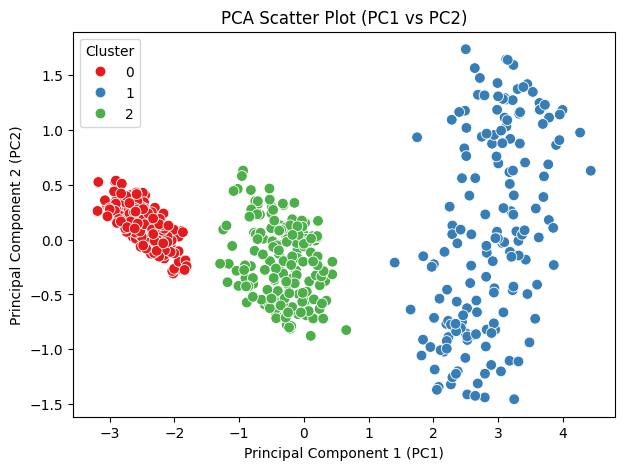

In [7]:
# Task 5. Cluster Visualisation

# Creating DataFrame with PCA results + cluster labels
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = customers['Cluster']

# Plotting
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=60
)

plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Cluster")

plt.show()